# Round 1 Baseline: Logistic Regression CTR

This notebook implements Member D's Logistic Regression CTR baseline for the round 1 ranking task on the MIND dataset. The goal is to predict the click probability for each impression-candidate pair and evaluate the ranking quality under the same round 1 protocol used by the other baseline methods.

To keep the comparison fair and reproducible, this notebook follows the common round 1 setting below:
- same train/validation split:
  - train: `data/train/*`
  - validation: `data/valid/*`
- same random seed: `42`
- same evaluation metrics:
  - `AUC`
  - `MRR`
  - `nDCG@5`
  - `nDCG@10`

The feature design in this baseline is intentionally lightweight and interpretable. It combines candidate news attributes, simple text-length statistics, user history signals, and basic time features, without using text embeddings or heavy feature engineering.

The final saved baseline result in this notebook is:
- `AUC = 0.6112`
- `MRR = 0.3130`
- `nDCG@5 = 0.3005`
- `nDCG@10 = 0.3640`


## Outline

This notebook follows the steps below:

1. Setup the environment and file paths
2. Load candidate-level and news data
3. Merge the data and build lightweight CTR features
4. Prepare model inputs and train Logistic Regression
5. Run a lightweight tuning check
6. Predict and evaluate the ranking result
7. Interpret the model and summarize the baseline


## 1. Setup

In this section we define the project root, input file paths, output directory, and random seed.  
The notebook is designed to run inside the project `.venv` environment.

In [29]:
from __future__ import annotations

import json
import random
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd().parent
TRAIN_CANDIDATES_PATH = PROJECT_ROOT / "outputs/shared/train_candidates.csv"
VALID_CANDIDATES_PATH = PROJECT_ROOT / "outputs/shared/valid_candidates.csv"
TRAIN_NEWS_PATH = PROJECT_ROOT / "data/train/news.tsv"
VALID_NEWS_PATH = PROJECT_ROOT / "data/valid/news.tsv"
OUTPUT_DIR = PROJECT_ROOT / "outputs/lr_ctr"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for path in [TRAIN_CANDIDATES_PATH, VALID_CANDIDATES_PATH, TRAIN_NEWS_PATH, VALID_NEWS_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")

print("Project root:", PROJECT_ROOT)
print("Seed:", SEED)
print("Output directory:", OUTPUT_DIR)


Project root: /Users/apple/Desktop/Microsoft/2026-MDSH-Submit
Seed: 42
Output directory: /Users/apple/Desktop/Microsoft/2026-MDSH-Submit/outputs/lr_ctr


## 2. Load Candidate Data

The shared candidate files are the sample backbone of this task.  
Each row represents one **impression-candidate** pair, which is exactly the level required by the unified evaluator.

Important distinction:
- `news.tsv` is a news table, so each row is one news item
- `behaviors.tsv` is an impression table, so each row is one impression
- `outputs/shared/*.csv` is an expanded candidate table, so each row is one impression-candidate pair

In [30]:
train_candidates = pd.read_csv(
    TRAIN_CANDIDATES_PATH,
    dtype={"impression_id": str, "user_id": str, "candidate_news_id": str},
)
valid_candidates = pd.read_csv(
    VALID_CANDIDATES_PATH,
    dtype={"impression_id": str, "user_id": str, "candidate_news_id": str},
)

train_candidates["history"] = train_candidates["history"].fillna("")
valid_candidates["history"] = valid_candidates["history"].fillna("")

print("Train candidates:", train_candidates.shape)
print("Valid candidates:", valid_candidates.shape)
display(train_candidates.head())


Train candidates: (5843444, 7)
Valid candidates: (2740998, 7)


,impression_id,user_id,time,history,candidate_news_id,label,candidate_pos
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689,1,0
1,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N35729,0,1
2,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678,0,0
3,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N39317,0,1
4,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N58114,0,2


## 3. Load News Data

The candidate files do not contain enough news attributes for CTR feature engineering.  
So we also load the raw news tables and keep the fields needed for this baseline.

In this version, we use raw news metadata and lightweight text-length statistics, but we do not use embeddings.

In [31]:
NEWS_COLUMNS = [
    "news_id",
    "category",
    "subcategory",
    "title",
    "abstract",
    "url",
    "title_entities",
    "abstract_entities",
]

train_news = pd.read_csv(TRAIN_NEWS_PATH, sep="\t", header=None, names=NEWS_COLUMNS, dtype=str)
valid_news = pd.read_csv(VALID_NEWS_PATH, sep="\t", header=None, names=NEWS_COLUMNS, dtype=str)
news_df = pd.concat([train_news, valid_news], ignore_index=True)
news_df = news_df.drop_duplicates(subset=["news_id"]).reset_index(drop=True)
news_df["category"] = news_df["category"].fillna("unknown")
news_df["subcategory"] = news_df["subcategory"].fillna("unknown")
news_df["title"] = news_df["title"].fillna("")
news_df["abstract"] = news_df["abstract"].fillna("")
news_df["title_word_count"] = news_df["title"].str.split().str.len().fillna(0).astype(int)
news_df["abstract_word_count"] = news_df["abstract"].str.split().str.len().fillna(0).astype(int)
news_df["title_char_count"] = news_df["title"].str.len().astype(int)
news_df["abstract_char_count"] = news_df["abstract"].str.len().astype(int)

print("Combined news table:", news_df.shape)
display(news_df[["news_id", "category", "subcategory", "title", "abstract"]].head())


Combined news table: (65238, 12)


,news_id,category,subcategory,title,abstract
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the..."
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...
3,N53526,health,voices,I Was An NBA Wife. Here's How It Affected My M...,"I felt like I was a fraud, and being an NBA wi..."
4,N38324,health,medical,"How to Get Rid of Skin Tags, According to a De...","They seem harmless, but there's a very good re..."


## 4. Merge Candidate Samples With News Attributes

Here we match each `candidate_news_id` from the candidate samples with the corresponding `news_id` in the news table.  
This gives each sample access to candidate news attributes, including category, subcategory, and simple text-length features.

In [32]:
news_features = news_df[[
    "news_id",
    "category",
    "subcategory",
    "title_word_count",
    "abstract_word_count",
    "title_char_count",
    "abstract_char_count",
]].copy()

train_df = train_candidates.merge(news_features, left_on="candidate_news_id", right_on="news_id", how="left")
valid_df = valid_candidates.merge(news_features, left_on="candidate_news_id", right_on="news_id", how="left")

train_df["category"] = train_df["category"].fillna("unknown")
train_df["subcategory"] = train_df["subcategory"].fillna("unknown")
valid_df["category"] = valid_df["category"].fillna("unknown")
valid_df["subcategory"] = valid_df["subcategory"].fillna("unknown")

display(train_df[["candidate_news_id", "category", "subcategory"]].head())


,candidate_news_id,category,subcategory
0,N55689,sports,football_nfl
1,N35729,news,newsus
2,N20678,sports,more_sports
3,N39317,news,newspolitics
4,N58114,autos,autosnews


## 5. Feature Engineering

This final baseline uses 15 lightweight features. They fall into four groups:

- history size features: `history_len`, `history_unique_len`
- history-match features: `same_category_count`, `same_subcategory_count`, `same_category_ratio`, `same_subcategory_ratio`
- context features: `hour`, `weekday`, `is_weekend`
- candidate news features: `title_word_count`, `abstract_word_count`, `title_char_count`, `abstract_char_count`, `category`, `subcategory`

The main idea is simple: if the current candidate is similar to what the user has clicked before, has favorable time context, and carries useful lightweight content signals, the click probability should be higher.

In [33]:
category_map = dict(zip(news_df["news_id"], news_df["category"]))
subcategory_map = dict(zip(news_df["news_id"], news_df["subcategory"]))

def count_history_matches(history: str, target: str, value_map: dict[str, str]) -> int:
    if not history or not target or target == "unknown":
        return 0
    return sum(1 for news_id in history.split() if value_map.get(news_id) == target)

def add_basic_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    histories = df["history"].apply(lambda x: x.split() if isinstance(x, str) and x else [])
    df["history_len"] = histories.apply(len)
    df["history_unique_len"] = histories.apply(lambda items: len(set(items)))

    parsed_time = pd.to_datetime(df["time"], errors="coerce")
    df["hour"] = parsed_time.dt.hour.fillna(-1).astype(int)
    df["weekday"] = parsed_time.dt.dayofweek.fillna(-1).astype(int)
    df["is_weekend"] = df["weekday"].isin([5, 6]).astype(int)

    df["same_category_count"] = df.apply(
        lambda row: count_history_matches(row["history"], row["category"], category_map), axis=1
    )
    df["same_subcategory_count"] = df.apply(
        lambda row: count_history_matches(row["history"], row["subcategory"], subcategory_map), axis=1
    )

    history_len_safe = df["history_len"].replace(0, 1)
    df["same_category_ratio"] = df["same_category_count"] / history_len_safe
    df["same_subcategory_ratio"] = df["same_subcategory_count"] / history_len_safe
    return df

train_df = add_basic_features(train_df)
valid_df = add_basic_features(valid_df)

FEATURE_COLUMNS = [
    "history_len",
    "history_unique_len",
    "same_category_count",
    "same_subcategory_count",
    "same_category_ratio",
    "same_subcategory_ratio",
    "hour",
    "weekday",
    "is_weekend",
    "title_word_count",
    "abstract_word_count",
    "title_char_count",
    "abstract_char_count",
    "category",
    "subcategory",
]

display(train_df[FEATURE_COLUMNS + ["label"]].head())


,history_len,history_unique_len,same_category_count,same_subcategory_count,same_category_ratio,same_subcategory_ratio,hour,weekday,is_weekend,title_word_count,abstract_word_count,title_char_count,abstract_char_count,category,subcategory,label
0,9,9,2,0,0.222222,0.0,9,0,0,12,24,78,145,sports,football_nfl,1
1,9,9,3,0,0.333333,0.0,9,0,0,11,19,68,100,news,newsus,0
2,82,81,3,0,0.036585,0.0,18,1,0,15,13,83,85,sports,more_sports,0
3,82,81,54,0,0.658537,0.0,18,1,0,11,22,69,129,news,newspolitics,0
4,82,81,0,0,0.000000,0.0,18,1,0,11,0,71,0,autos,autosnews,0


## 6. Prepare Model Inputs

We separate the features into numeric columns and categorical columns.  
This matters because Logistic Regression cannot consume raw string categories directly.

Numeric features in this final version include history size, history-match counts and ratios, time features, and text-length statistics.  
Categorical features are `category` and `subcategory`.

In [34]:
NUMERIC_FEATURES = [
    "history_len",
    "history_unique_len",
    "same_category_count",
    "same_subcategory_count",
    "same_category_ratio",
    "same_subcategory_ratio",
    "hour",
    "weekday",
    "is_weekend",
    "title_word_count",
    "abstract_word_count",
    "title_char_count",
    "abstract_char_count",
]
CATEGORICAL_FEATURES = ["category", "subcategory"]

X_train = train_df[FEATURE_COLUMNS]
y_train = train_df["label"].astype(int)
X_valid = valid_df[FEATURE_COLUMNS]
y_valid = valid_df["label"].astype(int)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("Train CTR:", round(float(y_train.mean()), 4))
print("Valid CTR:", round(float(y_valid.mean()), 4))


X_train: (5843444, 15)
X_valid: (2740998, 15)
Train CTR: 0.0404
Valid CTR: 0.0406


## 7. Build Logistic Regression Pipeline

The preprocessing and the model are packaged into a single scikit-learn pipeline.

- numeric features: impute missing values and standardize
- categorical features: impute missing values and one-hot encode
- model: Logistic Regression

This keeps training and inference consistent and easy to reproduce.

In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
                    ("scaler", StandardScaler()),
                ]
            ),
            NUMERIC_FEATURES,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            CATEGORICAL_FEATURES,
        ),
    ]
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=SEED)),
    ]
)

pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## 8. Train the Model and Lightweight Tuning

We first train the baseline Logistic Regression model on the full train candidate table.  
Then we run a small tuning check with a few `C` and `class_weight` settings to compare whether the ranking metrics improve.

The main saved prediction and evaluation below still correspond to the baseline run, while the tuning block is used as a compact comparison experiment.


In [36]:
pipeline.fit(X_train, y_train)
print("Training finished.")


Training finished.


### Optional Lightweight Tuning Check

Using the same 15-feature design, we test only a few representative settings.

Hyperparameters checked here:
- `C`: regularization strength
- `class_weight`: whether to rebalance positive and negative samples

The goal is not exhaustive optimization, but a quick check of whether simple parameter changes improve ranking performance.


In [37]:
def evaluate_predictions(df: pd.DataFrame) -> dict:
    auc_list, mrr_list, ndcg5_list, ndcg10_list = [], [], [], []

    for _, g in df.groupby("impression_id", sort=False):
        y = g["label"].to_numpy(dtype=int)
        s = g["score"].to_numpy(dtype=float)

        pos = np.sum(y == 1)
        neg = np.sum(y == 0)
        if pos > 0 and neg > 0:
            order = np.argsort(s)
            ranks = np.empty_like(order, dtype=float)
            ranks[order] = np.arange(1, len(s) + 1)
            pos_ranks = ranks[y == 1].sum()
            auc_val = float((pos_ranks - pos * (pos + 1) / 2.0) / (pos * neg))
            auc_list.append(auc_val)

        order_desc = np.argsort(-s)
        sorted_y = y[order_desc]
        pos_idx = np.where(sorted_y == 1)[0]
        mrr_list.append(float(1.0 / (pos_idx[0] + 1)) if len(pos_idx) else 0.0)

        for k, collector in [(5, ndcg5_list), (10, ndcg10_list)]:
            top_idx = np.argsort(-s)[:k]
            gains = y[top_idx].astype(float)
            discounts = 1.0 / np.log2(np.arange(2, len(gains) + 2))
            dcg = float(np.sum(gains * discounts))
            ideal = np.sort(y)[::-1][:k].astype(float)
            idcg = float(np.sum(ideal * discounts[: len(ideal)]))
            collector.append(0.0 if idcg == 0 else dcg / idcg)

    return {
        "AUC": float(np.mean(auc_list)) if auc_list else None,
        "MRR": float(np.mean(mrr_list)) if mrr_list else None,
        "nDCG@5": float(np.mean(ndcg5_list)) if ndcg5_list else None,
        "nDCG@10": float(np.mean(ndcg10_list)) if ndcg10_list else None,
    }

tuning_configs = [
    {"name": "baseline_l2_c1", "C": 1.0, "penalty": "l2", "solver": "lbfgs", "class_weight": None},
    {"name": "l2_c0.1", "C": 0.1, "penalty": "l2", "solver": "lbfgs", "class_weight": None},
    {"name": "l2_balanced", "C": 1.0, "penalty": "l2", "solver": "lbfgs", "class_weight": "balanced"},
]

tuning_records = []
for config in tuning_configs:
    trial_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "model",
                LogisticRegression(
                    max_iter=1000,
                    random_state=SEED,
                    C=config["C"],
                    penalty=config["penalty"],
                    solver=config["solver"],
                    class_weight=config["class_weight"],
                ),
            ),
        ]
    )

    trial_pipeline.fit(X_train, y_train)
    trial_scores = trial_pipeline.predict_proba(X_valid)[:, 1]
    trial_predictions = valid_df[["impression_id", "candidate_news_id", "label"]].copy()
    trial_predictions["score"] = trial_scores
    trial_metrics = evaluate_predictions(trial_predictions)

    tuning_records.append(
        {
            "name": config["name"],
            "C": config["C"],
            "penalty": config["penalty"],
            "solver": config["solver"],
            "class_weight": config["class_weight"],
            **trial_metrics,
        }
    )

tuning_df = pd.DataFrame(tuning_records).sort_values(["AUC", "MRR"], ascending=False)
display(tuning_df)


/Users/apple/Desktop/Microsoft/2026-MDSH-Submit/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/apple/Desktop/Microsoft/2026-MDSH-Submit/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/apple/Desktop/Microsoft/2026-MDSH-Submit/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: Fut

,name,C,penalty,solver,class_weight,AUC,MRR,nDCG@5,nDCG@10
1,l2_c0.1,0.1,l2,lbfgs,None,0.611751,0.314086,0.301777,0.364585
2,l2_balanced,1.0,l2,lbfgs,balanced,0.611626,0.311340,0.298791,0.362839
0,baseline_l2_c1,1.0,l2,lbfgs,None,0.611166,0.312957,0.300541,0.363970


The tuning table shows that `l2_c0.1` performs best among the tested settings, with slightly higher `AUC`, `MRR`, `nDCG@5`, and `nDCG@10` than the baseline.

Because this notebook is primarily organized around one clean baseline pipeline, the saved prediction file, metrics file, and later coefficient analysis still correspond to the baseline `l2` model with `C=1.0`. The tuning block is included as a lightweight comparison experiment.


## 9. Predict On Validation Set

For each validation candidate, the model outputs `P(click=1)`.  
That probability becomes the ranking `score` used by the unified evaluator.

In [38]:
valid_scores = pipeline.predict_proba(X_valid)[:, 1]
predictions = valid_df[["impression_id", "candidate_news_id"]].copy()
predictions["score"] = valid_scores

prediction_path = OUTPUT_DIR / "prediction.txt"
predictions.to_csv(prediction_path, index=False)

display(predictions.head())
print("Saved prediction file to:", prediction_path)


,impression_id,candidate_news_id,score
0,1,N28682,0.037428
1,1,N48740,0.046735
2,1,N31958,0.037271
3,1,N34130,0.069277
4,1,N6916,0.025277


Saved prediction file to: /Users/apple/Desktop/Microsoft/2026-MDSH-Submit/outputs/lr_ctr/prediction.txt


## 10. Run Unified Evaluation

The prediction file is evaluated with the shared round 1 script.  
This ensures that our Logistic Regression baseline is measured with the same protocol as the other round 1 methods.

In [39]:
cmd = [
    str(PROJECT_ROOT / ".venv" / "bin" / "python"),
    str(PROJECT_ROOT / "task_assignment" / "eval_round1.py"),
    "--predictions",
    str(prediction_path),
    "--method-name",
    "lr_ctr",
]
subprocess.run(cmd, cwd=PROJECT_ROOT, check=True)


{
  "impressions_total": 73152,
  "impressions_with_auc": 73152,
  "AUC": 0.6111663955440165,
  "MRR": 0.3129568063952958,
  "nDCG@5": 0.3005408655271237,
  "nDCG@10": 0.3639699700992944
}
Wrote metrics to: outputs/lr_ctr/metrics.json
Updated leaderboard: outputs/leaderboard_round1.csv


CompletedProcess(args=['/Users/apple/Desktop/Microsoft/2026-MDSH-Submit/.venv/bin/python', '/Users/apple/Desktop/Microsoft/2026-MDSH-Submit/task_assignment/eval_round1.py', '--predictions', '/Users/apple/Desktop/Microsoft/2026-MDSH-Submit/outputs/lr_ctr/prediction.txt', '--method-name', 'lr_ctr'], returncode=0)

## 11. Inspect Saved Outputs

At this point we inspect the saved metric file and the run log.  
These are the artifacts that matter most for reporting and comparison.

In [40]:
metrics_path = OUTPUT_DIR / "metrics.json"
run_log_path = OUTPUT_DIR / "run.log"

run_log = {
    "method_name": "lr_ctr",
    "seed": SEED,
    "feature_columns": FEATURE_COLUMNS,
    "train_rows": int(len(train_df)),
    "valid_rows": int(len(valid_df)),
    "prediction_path": str(prediction_path),
}
with run_log_path.open("w", encoding="utf-8") as f:
    json.dump(run_log, f, ensure_ascii=False, indent=2)

with metrics_path.open("r", encoding="utf-8") as f:
    metrics = json.load(f)

print("Saved run log to:", run_log_path)
print(json.dumps(metrics, ensure_ascii=False, indent=2))


Saved run log to: /Users/apple/Desktop/Microsoft/2026-MDSH-Submit/outputs/lr_ctr/run.log
{
  "impressions_total": 73152,
  "impressions_with_auc": 73152,
  "AUC": 0.6111663955440165,
  "MRR": 0.3129568063952958,
  "nDCG@5": 0.3005408655271237,
  "nDCG@10": 0.3639699700992944
}


## 12. Coefficient Analysis

Because this is a Logistic Regression model, the learned coefficients provide a natural interpretation tool.

- positive coefficients push the click probability upward
- negative coefficients push the click probability downward
- larger absolute values indicate stronger influence in the linear model

For categorical variables, the coefficients are shown after one-hot encoding.

In our final model, the strongest positive coefficient is `cat__subcategory_sports_news`, while strong negative coefficients include `cat__subcategory_music-gallery` and `cat__subcategory_football_nfl_videos`. This suggests that subcategory information is one of the main drivers of the click prediction.


In [41]:
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
coefficients = pipeline.named_steps["model"].coef_[0]

coef_df = pd.DataFrame(
    {
        "feature": feature_names,
        "coefficient": coefficients,
        "abs_coefficient": np.abs(coefficients),
    }
).sort_values("abs_coefficient", ascending=False)

coef_path = OUTPUT_DIR / "coefficient_importance.csv"
coef_df.to_csv(coef_path, index=False)

print("Saved coefficient table to:", coef_path)
display(coef_df.head(15))


Saved coefficient table to: /Users/apple/Desktop/Microsoft/2026-MDSH-Submit/outputs/lr_ctr/coefficient_importance.csv


,feature,coefficient,abs_coefficient
206,cat__subcategory_sports_news,1.538621,1.538621
159,cat__subcategory_music-gallery,-1.138023,1.138023
107,cat__subcategory_football_nfl_videos,-1.013343,1.013343
212,cat__subcategory_topnews,0.980691,0.980691
162,cat__subcategory_musicnews,0.868816,0.868816
12,num__abstract_char_count,-0.762009,0.762009
223,cat__subcategory_tv-gallery,-0.761231,0.761231
158,cat__subcategory_music-celebrity,0.760804,0.760804
84,cat__subcategory_finance-companies,0.732134,0.732134
171,cat__subcategory_newsopinion,0.675811,0.675811


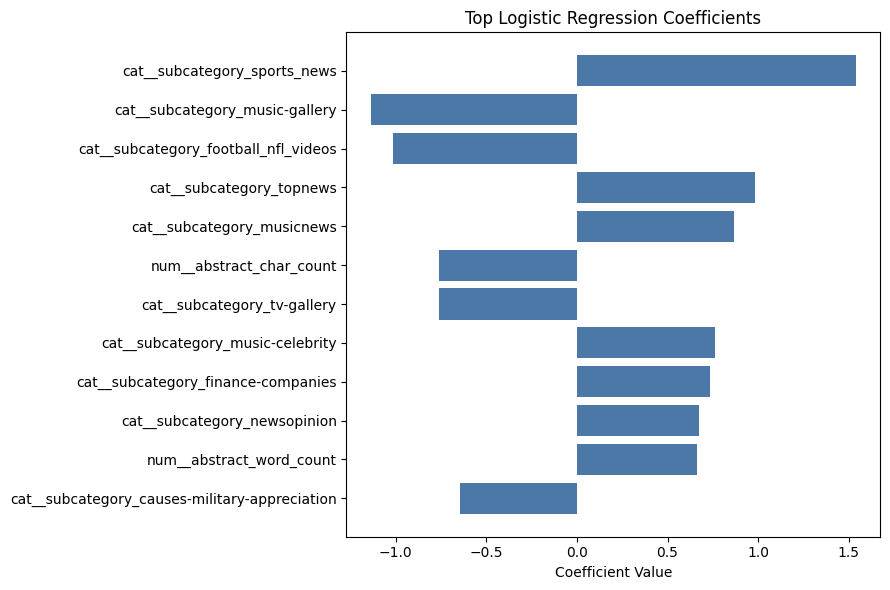

In [42]:
top_k = 12
plot_df = coef_df.head(top_k).iloc[::-1]

plt.figure(figsize=(9, 6))
plt.barh(plot_df["feature"], plot_df["coefficient"], color="#4C78A8")
plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()


This plot highlights the most influential Logistic Regression coefficients.

The largest positive coefficient is `cat__subcategory_sports_news`, while `cat__subcategory_music-gallery` and `cat__subcategory_football_nfl_videos` are among the strongest negative signals. `num__abstract_char_count` and `num__abstract_word_count` also appear near the top, showing that simple text-length information contributes alongside news-topic features.


## 13. Summary and Conclusion

This notebook builds a Logistic Regression CTR baseline on candidate-level samples from `outputs/shared/`, then enriches them with raw news attributes from `news.tsv`.

Data used in this notebook:
- train candidates: about `5.84M`
- valid candidates: about `2.74M`
- combined news table: about `65K`

Feature groups used in the final baseline model:
- history size: `history_len`, `history_unique_len`
- history-match: `same_category_count`, `same_subcategory_count`, `same_category_ratio`, `same_subcategory_ratio`
- context: `hour`, `weekday`, `is_weekend`
- candidate news: `category`, `subcategory`, `title_word_count`, `abstract_word_count`, `title_char_count`, `abstract_char_count`

Saved baseline validation performance:
- `AUC = 0.6112`
- `MRR = 0.3130`
- `nDCG@5 = 0.3005`
- `nDCG@10 = 0.3640`

The lightweight tuning check suggests that a small parameter change such as `C=0.1` can further improve the metrics slightly. Overall, this notebook shows that a simple linear CTR model can already provide a strong and interpretable round 1 baseline when paired with careful feature engineering.


## 14. Future Work

This baseline can be extended in several directions.

- For Logistic Regression itself, future work could test richer text representations, including text embeddings from the title or abstract instead of only lightweight length statistics.
- Additional train-level statistics or broader parameter tuning could also be explored.
- More importantly for the project, this baseline now gives us a clear reference point for comparing the more advanced recommendation models in the `recommenders/` repository.
